In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ordner = "/content/Daten"
dateien = glob.glob(os.path.join(ordner, "*.csv"))

df_liste = []

for datei in dateien:
    df_temp = pd.read_csv(datei, engine="python", on_bad_lines="skip", sep=";")
    df_temp["quelle_datei"] = os.path.basename(datei)
    df_liste.append(df_temp)

df = pd.concat(df_liste, ignore_index=True)

print(df.head())
print(df.info())

           english_term         spanish_term  migrationsbezug_eng  \
0  Acquired citizenship  Ciudadanía Derivada                    1   
1  Acquired citizenship  Ciudadanía Derivada                    1   
2  Acquired citizenship  Ciudadanía Derivada                    1   
3  Acquired citizenship  Ciudadanía Derivada                    1   
4  Acquired citizenship  Ciudadanía Derivada                    1   

   migrationsbezug_spa  polysemie_eng  polysemie_spa  topic_number  \
0                    1              0              0             1   
1                    1              0              0             1   
2                    1              0              0             1   
3                    1              0              0             1   
4                    1              0              0             1   

                               topic  migrationsbezug_equal  \
0  Rechtlicher Status und Aufenthalt                      1   
1  Rechtlicher Status und Aufenthalt  

In [2]:
clean_df = df[
    ~(
        (
            (df['qs_eng'].notna() & df['qs_migrationsbezug_eng_final'].isna()) |
            (df['qs_spa'].notna() & df['qs_migrationsbezug_spa_final'].isna())
        )
        |
        (df['english_term'] == "Naturalization certificate")
        |
         (df['english_term'] == "Petitioner")
        |
         (df['english_term'] == "Smuggling of migrants")
        |
         (df['english_term'] == "foreigner")

    )
].copy()

In [14]:
result = (
    clean_df
    .assign(
        Anzahl_englische_QS = clean_df['qs_eng'].notna().astype(int),
        Anzahl_spanische_QS = clean_df['qs_spa'].notna().astype(int)
    )
    .groupby('land')[['Anzahl_englische_QS', 'Anzahl_spanische_QS']]
    .sum()
    .reset_index()
)

In [15]:
result

,land,Anzahl_englische_QS,Anzahl_spanische_QS
0,Mexiko,103311,89896
1,USA,162134,141030


In [16]:
qs_eng_land = clean_df.groupby('land')['qs_migrationsbezug_eng_final'].mean()

In [17]:
qs_spa_land = clean_df.groupby('land')['qs_migrationsbezug_spa_final'].mean()

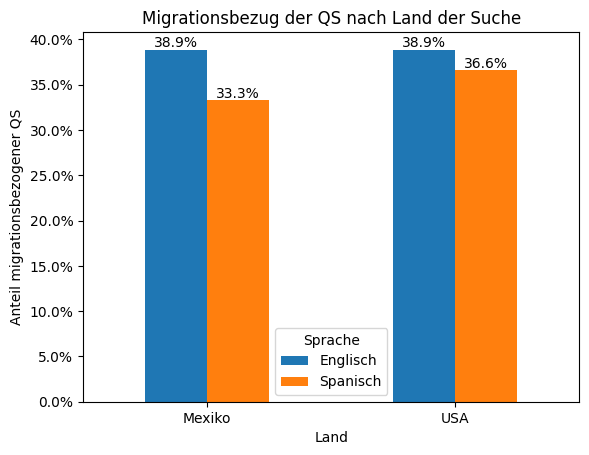

In [18]:
import matplotlib.ticker as mtick
# DataFrame erstellen
df_plot = pd.DataFrame({
    'Englisch': qs_eng_land,
    'Spanisch': qs_spa_land
})

ax = df_plot.plot(kind='bar')

# Titel & Labels
ax.set_title("Migrationsbezug der QS nach Land der Suche")
ax.set_ylabel("Anteil migrationsbezogener QS")
ax.set_xlabel("Land")

# Y-Achse in Prozent umwandeln
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Prozentwerte über die Balken schreiben
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')

plt.xticks(rotation=0)
plt.legend(title="Sprache")

plt.show()

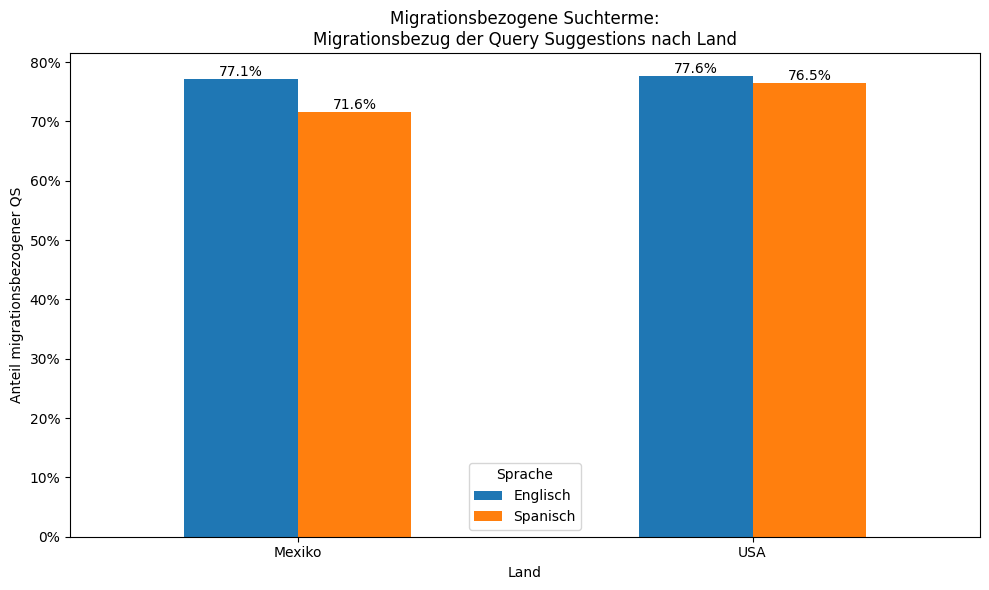

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Filtern
df_eng_with = clean_df[clean_df['migrationsbezug_eng'] == 1]
df_spa_with = clean_df[clean_df['migrationsbezug_spa'] == 1]

# Aggregieren
eng_with = df_eng_with.groupby('land')['qs_migrationsbezug_eng_final'].mean()
spa_with = df_spa_with.groupby('land')['qs_migrationsbezug_spa_final'].mean()

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# DataFrame
df_plot_with = pd.DataFrame({
    'Englisch': eng_with,
    'Spanisch': spa_with
})

ax = df_plot_with.plot(kind='bar', figsize=(10,6))

# Titel & Labels
ax.set_title("Migrationsbezogene Suchterme:\nMigrationsbezug der Query Suggestions nach Land")
ax.set_ylabel("Anteil migrationsbezogener QS")
ax.set_xlabel("Land")

# Prozent-Achse
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Prozentwerte über Balken
for p in ax.patches:
    height = p.get_height()
    if pd.notna(height):
        ax.annotate(f'{height:.1%}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom')

plt.xticks(rotation=0)
plt.legend(title="Sprache")
plt.tight_layout()
plt.show()

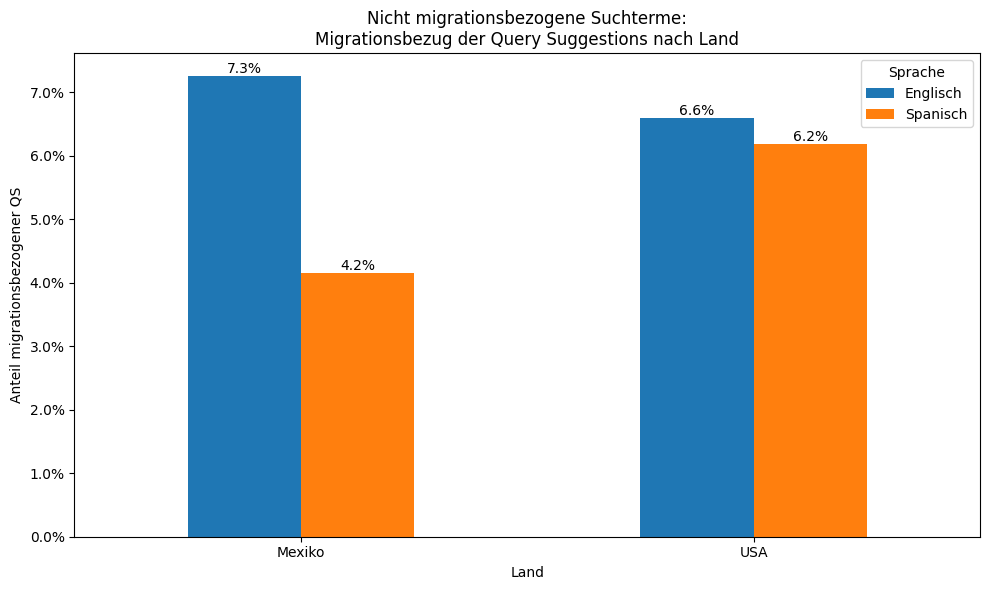

In [28]:
# Filtern
df_eng_without = clean_df[clean_df['migrationsbezug_eng'] == 0]
df_spa_without = clean_df[clean_df['migrationsbezug_spa'] == 0]

# Aggregieren
eng_without = df_eng_without.groupby('land')['qs_migrationsbezug_eng_final'].mean()
spa_without = df_spa_without.groupby('land')['qs_migrationsbezug_spa_final'].mean()

# DataFrame
df_plot_without = pd.DataFrame({
    'Englisch': eng_without,
    'Spanisch': spa_without
})

ax = df_plot_without.plot(kind='bar', figsize=(10,6))

# Titel & Labels
ax.set_title("Nicht migrationsbezogene Suchterme:\nMigrationsbezug der Query Suggestions nach Land")
ax.set_ylabel("Anteil migrationsbezogener QS")
ax.set_xlabel("Land")

# Prozent-Achse
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Prozentwerte über Balken
for p in ax.patches:
    height = p.get_height()
    if pd.notna(height):
        ax.annotate(f'{height:.1%}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom')

plt.xticks(rotation=0)
plt.legend(title="Sprache")
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import plotly.express as px
import requests
import unicodedata

# -----------------------------
# 1) Hilfsfunktionen
# -----------------------------
def normalize_text(s):
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    s = ''.join(c for c in unicodedata.normalize('NFD', s)
                if unicodedata.category(c) != 'Mn')
    return s

def print_min_max(df, value_col, label):
    min_val = df[value_col].min()
    max_val = df[value_col].max()
    print(f"{label}: min = {min_val:.1%}, max = {max_val:.1%}")

# -----------------------------
# 2) USA-Daten vorbereiten
#    nur NICHT migrationsbezogene Terme
# -----------------------------
usa_states = (
    clean_df[clean_df['land'] == 'USA']
    .groupby('bundesstaat')
    .agg(
        qs_migrationsbezug_eng_final=('qs_migrationsbezug_eng_final',
                                      lambda x: x[clean_df.loc[x.index, 'migrationsbezug_eng'] == 0].mean()),
        qs_migrationsbezug_spa_final=('qs_migrationsbezug_spa_final',
                                      lambda x: x[clean_df.loc[x.index, 'migrationsbezug_spa'] == 0].mean())
    )
    .reset_index()
)

state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

usa_states['state_code'] = usa_states['bundesstaat'].map(state_abbrev)

# -----------------------------
# 3) Min/Max USA ausgeben
# -----------------------------
print_min_max(usa_states, 'qs_migrationsbezug_spa_final', 'USA Spanisch ohne migrationsbezogene Terme')
print_min_max(usa_states, 'qs_migrationsbezug_eng_final', 'USA Englisch ohne migrationsbezogene Terme')

# -----------------------------
# 4) USA-Karte Spanisch
# -----------------------------
fig_usa_spa = px.choropleth(
    usa_states,
    locations='state_code',
    locationmode='USA-states',
    color='qs_migrationsbezug_spa_final',
    scope='usa',
    hover_name='bundesstaat',
    hover_data={
        'qs_migrationsbezug_spa_final': ':.1%',
        'state_code': False
    },
    color_continuous_scale='Reds',
    range_color=(
        usa_states['qs_migrationsbezug_spa_final'].min(),
        usa_states['qs_migrationsbezug_spa_final'].max()
    ),
    title='USA: Migrationsbezug der spanischen Query Suggestions bei nicht migrationsbezogenen Suchtermen'
)

fig_usa_spa.update_layout(
    coloraxis_colorbar=dict(
        title='Anteil',
        tickformat='.2%'
    )
)

fig_usa_spa.show()

# -----------------------------
# 5) USA-Karte Englisch
# -----------------------------
fig_usa_eng = px.choropleth(
    usa_states,
    locations='state_code',
    locationmode='USA-states',
    color='qs_migrationsbezug_eng_final',
    scope='usa',
    hover_name='bundesstaat',
    hover_data={
        'qs_migrationsbezug_eng_final': ':.1%',
        'state_code': False
    },
    color_continuous_scale='Blues',
    range_color=(
        usa_states['qs_migrationsbezug_eng_final'].min(),
        usa_states['qs_migrationsbezug_eng_final'].max()
    ),
    title='USA: Migrationsbezug der englischen Query Suggestions bei nicht migrationsbezogenen Suchtermen'
)

fig_usa_eng.update_layout(
    coloraxis_colorbar=dict(
        title='Anteil',
        tickformat='.2%'
    )
)

fig_usa_eng.show()

# -----------------------------
# 6) Mexiko-Daten vorbereiten
#    nur NICHT migrationsbezogene Terme
# -----------------------------
mex_states = (
    clean_df[clean_df['land'].isin(['Mexiko', 'Mexico'])]
    .groupby('bundesstaat')
    .agg(
        qs_migrationsbezug_eng_final=('qs_migrationsbezug_eng_final',
                                      lambda x: x[clean_df.loc[x.index, 'migrationsbezug_eng'] == 0].mean()),
        qs_migrationsbezug_spa_final=('qs_migrationsbezug_spa_final',
                                      lambda x: x[clean_df.loc[x.index, 'migrationsbezug_spa'] == 0].mean())
    )
    .reset_index()
)

mex_states['bundesstaat_norm'] = mex_states['bundesstaat'].apply(normalize_text)

# GeoJSON für mexikanische Bundesstaaten laden
geojson_url = "https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json"
mexico_geojson = requests.get(geojson_url).json()

# Namen normalisieren
for feature in mexico_geojson['features']:
    feature['properties']['name_norm'] = normalize_text(feature['properties']['name'])

# -----------------------------
# 7) Prüfen, ob Namen matchen
# -----------------------------
geojson_names = {f['properties']['name_norm'] for f in mexico_geojson['features']}
data_names = set(mex_states['bundesstaat_norm'])

missing_in_geojson = sorted(data_names - geojson_names)
if missing_in_geojson:
    print("Diese Bundesstaaten aus deinen Daten wurden im GeoJSON nicht gefunden:")
    print(missing_in_geojson)

# -----------------------------
# 8) Min/Max Mexiko ausgeben
# -----------------------------
print_min_max(mex_states, 'qs_migrationsbezug_spa_final', 'Mexiko Spanisch ohne migrationsbezogene Terme')
print_min_max(mex_states, 'qs_migrationsbezug_eng_final', 'Mexiko Englisch ohne migrationsbezogene Terme')

# -----------------------------
# 9) Mexiko-Karte Spanisch
# -----------------------------
fig_mex_spa = px.choropleth(
    mex_states,
    geojson=mexico_geojson,
    locations='bundesstaat_norm',
    featureidkey='properties.name_norm',
    color='qs_migrationsbezug_spa_final',
    hover_name='bundesstaat',
    hover_data={
        'qs_migrationsbezug_spa_final': ':.1%',
        'bundesstaat_norm': False
    },
    color_continuous_scale='Reds',
    range_color=(
        mex_states['qs_migrationsbezug_spa_final'].min(),
        mex_states['qs_migrationsbezug_spa_final'].max()
    ),
    title='Mexiko: Migrationsbezug der spanischen Query Suggestions bei nicht migrationsbezogenen Suchtermen'
)

fig_mex_spa.update_geos(
    fitbounds="locations",
    visible=False
)

fig_mex_spa.update_layout(
    coloraxis_colorbar=dict(
        title='Anteil',
        tickformat='.2%'
    )
)

fig_mex_spa.show()

# -----------------------------
# 10) Mexiko-Karte Englisch
# -----------------------------
fig_mex_eng = px.choropleth(
    mex_states,
    geojson=mexico_geojson,
    locations='bundesstaat_norm',
    featureidkey='properties.name_norm',
    color='qs_migrationsbezug_eng_final',
    hover_name='bundesstaat',
    hover_data={
        'qs_migrationsbezug_eng_final': ':.1%',
        'bundesstaat_norm': False
    },
    color_continuous_scale='Blues',
    range_color=(
        mex_states['qs_migrationsbezug_eng_final'].min(),
        mex_states['qs_migrationsbezug_eng_final'].max()
    ),
    title='Mexiko: Migrationsbezug der englischen Query Suggestions bei nicht migrationsbezogenen Suchtermen'
)

fig_mex_eng.update_geos(
    fitbounds="locations",
    visible=False
)

fig_mex_eng.update_layout(
    coloraxis_colorbar=dict(
        title='Anteil',
        tickformat='.2%'
    )
)

fig_mex_eng.show()

USA Spanisch ohne migrationsbezogene Terme: min = 5.7%, max = 6.4%
USA Englisch ohne migrationsbezogene Terme: min = 6.2%, max = 7.4%


Diese Bundesstaaten aus deinen Daten wurden im GeoJSON nicht gefunden:
['mexico city', 'state of mexico']
Mexiko Spanisch ohne migrationsbezogene Terme: min = 3.8%, max = 4.5%
Mexiko Englisch ohne migrationsbezogene Terme: min = 6.9%, max = 7.5%


In [30]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

# Wir arbeiten auf dem partiell bereinigten Datensatz
df = clean_df.copy()

# Optional: nur Zeilen mit vorhandenen englischen bzw. spanischen QS
df_en = df[df['qs_eng'].notna()].copy()
df_es = df[df['qs_spa'].notna()].copy()

# Standort-ID bauen
df_en['location_id'] = (
    df_en['land'].astype(str) + " | " +
    df_en['bundesstaat'].astype(str) + " | " +
    df_en['stadt'].astype(str)
)

df_es['location_id'] = (
    df_es['land'].astype(str) + " | " +
    df_es['bundesstaat'].astype(str) + " | " +
    df_es['stadt'].astype(str)
)

def jaccard_similarity(set_a, set_b):
    """
    Jaccard-Index zwischen zwei Mengen.
    """
    if not set_a and not set_b:
        return np.nan
    union = set_a | set_b
    if len(union) == 0:
        return np.nan
    return len(set_a & set_b) / len(union)

# Pro Term und Standort die Menge der englischen Query Suggestions
term_location_sets = (
    df_en.groupby(
        ['english_term', 'land', 'bundesstaat', 'stadt', 'location_id']
    )['qs_eng']
    .apply(lambda x: set(x.dropna().astype(str).str.strip()))
    .reset_index(name='qs_set')
)

print(term_location_sets.head())

# Spanische Version
term_location_sets_spa = (
    df_es.groupby(
        ['spanish_term', 'land', 'bundesstaat', 'stadt', 'location_id']
    )['qs_spa']
    .apply(lambda x: set(x.dropna().astype(str).str.strip()))
    .reset_index(name='qs_set')
)

print(term_location_sets_spa.head())

  english_term    land          bundesstaat                      stadt  \
0     A-Number  Mexiko       Aguascalientes             Aguascalientes   
1     A-Number  Mexiko      Baja California                   Mexicali   
2     A-Number  Mexiko  Baja California Sur                     La Paz   
3     A-Number  Mexiko             Campeche  San Francisco de Campeche   
4     A-Number  Mexiko              Chiapas           Tuxtla Gutiérrez   

                                     location_id  \
0       Mexiko | Aguascalientes | Aguascalientes   
1            Mexiko | Baja California | Mexicali   
2          Mexiko | Baja California Sur | La Paz   
3  Mexiko | Campeche | San Francisco de Campeche   
4            Mexiko | Chiapas | Tuxtla Gutiérrez   

                                              qs_set  
0  {a-number/uscis number, a-number lookup, a-num...  
1  {a-number/uscis number, a-number lookup, a-num...  
2  {a-number/uscis number, a-number lookup, a-num...  
3  {a-number/uscis num

In [31]:
pairwise_results = []

for (term, land), group in term_location_sets.groupby(['english_term', 'land']):
    location_sets = list(zip(
        group['location_id'],
        group['land'],
        group['bundesstaat'],
        group['stadt'],
        group['qs_set']
    ))

    if len(location_sets) < 2:
        continue

    for (loc1, land1, bs1, stadt1, set1), (loc2, land2, bs2, stadt2, set2) in combinations(location_sets, 2):
        score = jaccard_similarity(set1, set2)
        pairwise_results.append({
            'sprache': 'Englisch',
            'term': term,
            'land': land,
            'location_1': loc1,
            'bundesstaat_1': bs1,
            'stadt_1': stadt1,
            'location_2': loc2,
            'bundesstaat_2': bs2,
            'stadt_2': stadt2,
            'jaccard': score
        })

pairwise_df = pd.DataFrame(pairwise_results)
print(pairwise_df.head())

    sprache      term    land                                location_1  \
0  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
1  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
2  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
3  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
4  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   

    bundesstaat_1         stadt_1  \
0  Aguascalientes  Aguascalientes   
1  Aguascalientes  Aguascalientes   
2  Aguascalientes  Aguascalientes   
3  Aguascalientes  Aguascalientes   
4  Aguascalientes  Aguascalientes   

                                      location_2        bundesstaat_2  \
0            Mexiko | Baja California | Mexicali      Baja California   
1          Mexiko | Baja California Sur | La Paz  Baja California Sur   
2  Mexiko | Campeche | San Francisco de Campeche             Campeche   
3            Mexiko | Chiapas | Tu

In [32]:
pairwise_results_spa = []

for (term, land), group in term_location_sets_spa.groupby(['spanish_term', 'land']):
    location_sets = list(zip(
        group['location_id'],
        group['land'],
        group['bundesstaat'],
        group['stadt'],
        group['qs_set']
    ))

    if len(location_sets) < 2:
        continue

    for (loc1, land1, bs1, stadt1, set1), (loc2, land2, bs2, stadt2, set2) in combinations(location_sets, 2):
        score = jaccard_similarity(set1, set2)
        pairwise_results_spa.append({
            'sprache': 'Spanisch',
            'term': term,
            'land': land,
            'location_1': loc1,
            'bundesstaat_1': bs1,
            'stadt_1': stadt1,
            'location_2': loc2,
            'bundesstaat_2': bs2,
            'stadt_2': stadt2,
            'jaccard': score
        })

pairwise_df_spa = pd.DataFrame(pairwise_results_spa)
print(pairwise_df_spa.head())

    sprache                 term    land  \
0  Spanisch  Abogado en registro  Mexiko   
1  Spanisch  Abogado en registro  Mexiko   
2  Spanisch  Abogado en registro  Mexiko   
3  Spanisch  Abogado en registro  Mexiko   
4  Spanisch  Abogado en registro  Mexiko   

                                 location_1   bundesstaat_1         stadt_1  \
0  Mexiko | Aguascalientes | Aguascalientes  Aguascalientes  Aguascalientes   
1  Mexiko | Aguascalientes | Aguascalientes  Aguascalientes  Aguascalientes   
2  Mexiko | Aguascalientes | Aguascalientes  Aguascalientes  Aguascalientes   
3  Mexiko | Aguascalientes | Aguascalientes  Aguascalientes  Aguascalientes   
4  Mexiko | Aguascalientes | Aguascalientes  Aguascalientes  Aguascalientes   

                                      location_2        bundesstaat_2  \
0            Mexiko | Baja California | Mexicali      Baja California   
1          Mexiko | Baja California Sur | La Paz  Baja California Sur   
2  Mexiko | Campeche | San Francisco de C

In [33]:
combined_pairwise_df = pd.concat([pairwise_df, pairwise_df_spa], ignore_index=True)
print(combined_pairwise_df.head())

    sprache      term    land                                location_1  \
0  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
1  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
2  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
3  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   
4  Englisch  A-Number  Mexiko  Mexiko | Aguascalientes | Aguascalientes   

    bundesstaat_1         stadt_1  \
0  Aguascalientes  Aguascalientes   
1  Aguascalientes  Aguascalientes   
2  Aguascalientes  Aguascalientes   
3  Aguascalientes  Aguascalientes   
4  Aguascalientes  Aguascalientes   

                                      location_2        bundesstaat_2  \
0            Mexiko | Baja California | Mexicali      Baja California   
1          Mexiko | Baja California Sur | La Paz  Baja California Sur   
2  Mexiko | Campeche | San Francisco de Campeche             Campeche   
3            Mexiko | Chiapas | Tu

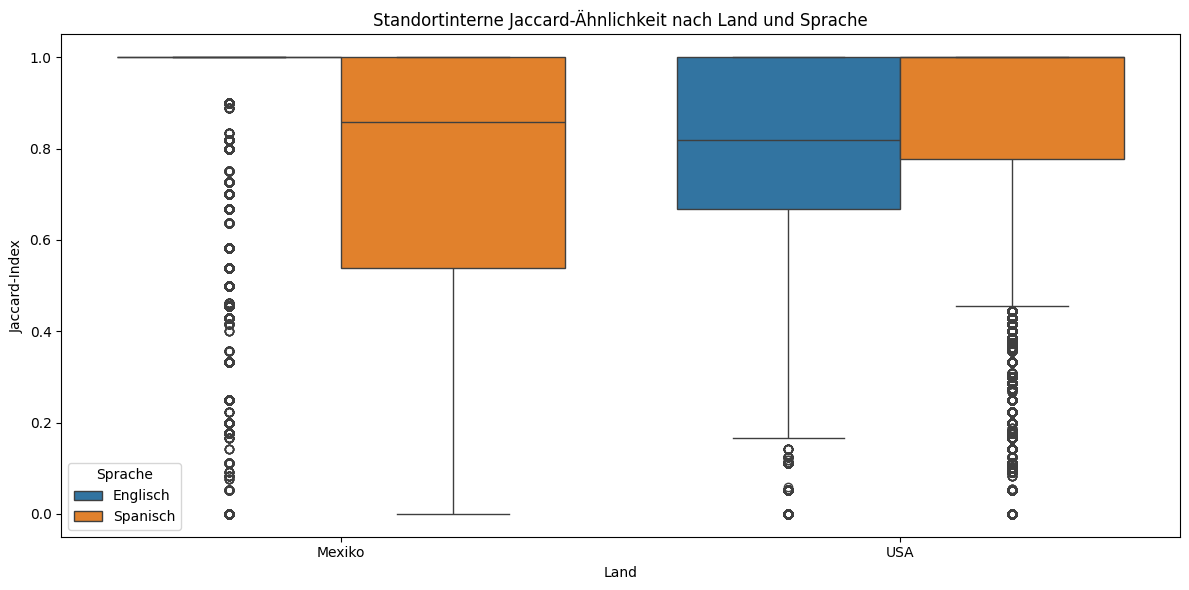

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=combined_pairwise_df,
    x='land',
    y='jaccard',
    hue='sprache'
)

plt.title("Standortinterne Jaccard-Ähnlichkeit nach Land und Sprache")
plt.xlabel("Land")
plt.ylabel("Jaccard-Index")
plt.legend(title="Sprache")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()